import numpy as np
import pandas as pd


In [48]:
import numpy as np
import pandas as pd

In [49]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [50]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3565,ham,Its ok..come to my home it vl nice to meet and...,NaN,NaN,NaN
4526,ham,Understand. his loss is my gain :) so do you w...,NaN,NaN,NaN
5422,ham,Ok k..sry i knw 2 siva..tats y i askd..,NaN,NaN,NaN
5506,ham,God's love has no limit. God's grace has no me...,NaN,NaN,NaN
797,ham,\Petey boy whereare you me and all your friend...,NaN,NaN,NaN


In [51]:
df.shape

(5572, 5)

In [52]:
#we follow the below steps to build our model
#1. Data cleaning
#2. EDA
#3. Text Preprocessing
#4. Model Building
#5. Evaluation
#6. Improvement
#7. Website
# Deployment

In [53]:
#above we see that the 3 unnamed columns have very less amount of data like, 50, 12, 6 non null values so we can drop those columns
#drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [54]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1464,ham,Wat makes u thk i'll fall down. But actually i...,NaN,NaN,NaN
1167,ham,Lol now I'm after that hot air balloon!,NaN,NaN,NaN
1569,ham,I dont have that much image in class.,NaN,NaN,NaN
1298,ham,Your daily text from me ÛÒ a favour this time,NaN,NaN,NaN
553,ham,Ok. Every night take a warm bath drink a cup o...,NaN,NaN,NaN


In [55]:
#rename the columns so that we can understand it better
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
876,ham,Are you in castor? You need to see something,NaN,NaN,NaN
3917,ham,No need to ke qi... ÌÏ too bored izzit y sudde...,NaN,NaN,NaN
1748,ham,Feel Yourself That You Are Always Happy.. Slow...,NaN,NaN,NaN
459,ham,Going thru a very different feeling.wavering d...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN


In [56]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
#Ml mode l can only understand the numerical values but our #target column have categorical values ham and spam so we #need to convert those categorical values into numerical #values ham =0 and spam =1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [58]:
#head is used to see the top 5 rows of the dataframe in pandas
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [59]:
#check missing values in the dataset
df.isnull().sum()
#there are no missing values in the dataset

target           0
text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [60]:
#chekc duplicated values in the dataset
df.duplicated().sum()
#there are 0 duplicated values in the dataset so we have successfully removed the duplicated values

np.int64(403)

In [61]:
#remove duplicated values
#keep = first means we will keep the first occurrence of the duplicated value and drop the rest
df = df.drop_duplicates(keep='first')

In [62]:
#again check duplicated values in the dataset
df.duplicated().sum()

np.int64(0)

In [63]:
#after removing duplicated values we have total 5169 rows and 2 columns in the dataset
df.shape

(5169, 5)

2.EDA

In [64]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [65]:
#check how many ham and spam messages are there in the #dataset
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

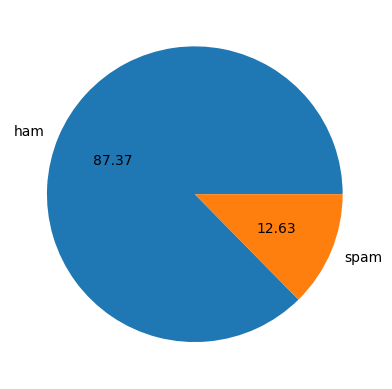

In [66]:
#visualization of ham and spam messages using pie chart
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()
#data is imbalanced because we have more ham messages than spam messages in the dataset

In [67]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
#we create 3 columns in the dataset for deeper analysis of the text data
#1. num_characters: number of characters in the text message
#2. num_words: number of words in the text message
#3. num_sentences: number of sentences in the text message
#to do this we need nltk library
#nltk is a natural language processing library in python which is used for text preprocessing and analysis
import nltk
#punkt is a pre-trained model in nltk which is used for tokenization of sentences and words
#we need to download the punkt model to load data into our model
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [69]:
#count number of characters in the text message in text column and store it in num_characters column
df['num_characters'] = df['text'].apply(len)

In [70]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61


In [71]:
#tokenize the text message into numbers and then count the number of words in the text message and store it in num_words column

#count number of words in the text message in text column and store it in num_words column

#nltk.word_tokenize is used to tokenize the text message into words and then we count the number of words in the text message

#lambda is an anonymous function in python which is used to create a function without a name

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [72]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15


In [73]:
#tokenize the text message into sentences and then count the number of sentences in the text message and store it in num_sentences column

#sent-tokenize is used to tokenize the text message into sentences and then we count the number of sentences in the text message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [74]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1


In [75]:
#here describe is used to get the statistical summary of the numerical columns in the dataset
#here maximum number of characters in the text message is 910 and 
# minimum number of characters in the text message is 2 and 
# average number of characters in the text message is 71.48
#maximum number of words in the text message is 152 and
# minimum number of words in the text message is 1 and
# average number of words in the text message is 13.05
#maximum number of sentences in the text message is 10 and
# minimum number of sentences in the text message is 1 and
# average number of sentences in the text message is 1.75
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [76]:
#here we will do the same analysis for ham messages only
#0 means ham messages and 1 means spam messages in the target column
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [77]:
#here we will do the same analysis for spam messages only
#0 means ham messages and 1 means spam messages in the target column
#minimum number of characters in the text message is 2 and
# average number of characters in the text message is 138.67 and
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()   

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [78]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: xlabel='num_characters', ylabel='Count'>

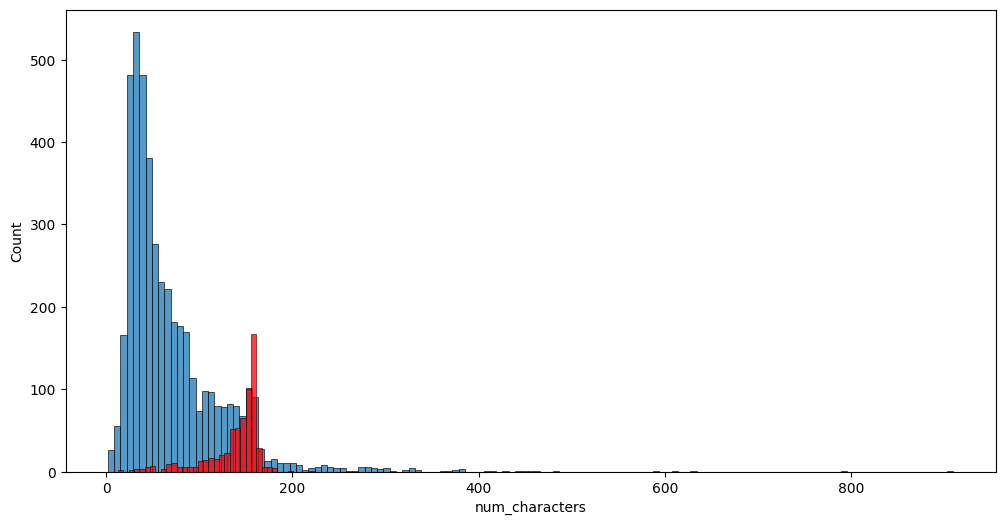

In [79]:
#we import seaborn library for data visualization
# we draw a histogram of num_characters column for ham and spam messages
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters']
,color='red')

<Axes: xlabel='num_words', ylabel='Count'>

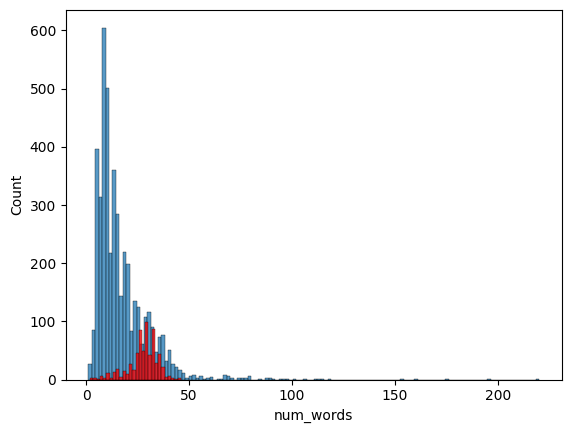

In [80]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words']
,color='red')

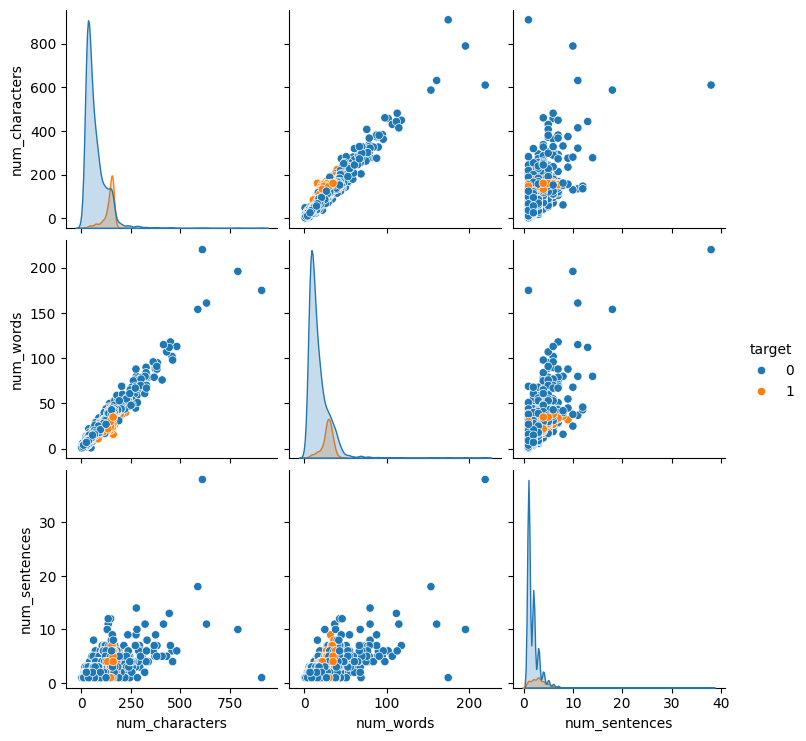

In [81]:
#now we can we can see  the relationship between num_characters, num_words and num_sentences columns with the target column using pairplot
sns.pairplot(df,hue='target')

<Axes: >

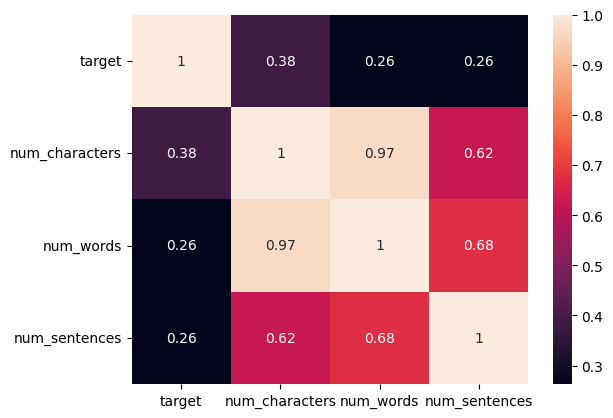

In [82]:
#heatmap is used to see the correlation between the numerical columns in the dataset
# corelation between target and num_characters is 0.38 which means there is a strong positive correlation between target and num_characters columns

#target vs num_characters (0.38): এখানে সম্পর্ক সবচেয়ে বেশি (০.৩৮)। এর মানে হলো, একটি মেসেজে কতগুলো অক্ষর আছে, তা দেখে স্প্যাম চেনার সম্ভাবনা সবচেয়ে বেশি।

#target vs num_words (0.26): এটিও গুরুত্বপূর্ণ, তবে ক্যারেক্টারের তুলনায় কিছুটা কম।

#target vs num_sentences (0.26): এটিও একই রকম প্রভাব ফেলে।
#এই চার্ট থেকে আমরা ৩টি সিদ্ধান্ত নিতে পারি:
#স্প্যাম মেসেজ সাধারণত বড় হয়: যেহেতু target এর সাথে num_characters এর একটি পজিটিভ সম্পর্ক আছে, তাই আমরা বলতে পারি মেসেজ যত বড় হবে, সেটি স্প্যাম হওয়ার সম্ভাবনা তত বাড়বে।

#কলাম বাছাই (Feature Selection): আপনার মডেল ট্রেইন করার সময় আপনি যদি শুধু একটি কলাম নিতে চান, তবে num_characters নেওয়া সবচেয়ে বুদ্ধিমানের কাজ হবে, কারণ এর কো-রিলেশন সবচেয়ে বেশি।

#অতিরিক্ত ডাটা: যেহেতু ক্যারেক্টার, শব্দ এবং বাক্য—এই তিনটিই একে অপরের সাথে খুব গভীরভাবে যুক্ত (০.৯৭), তাই তিনটিকে একসাথে মডেলে ব্যবহার করলে Multicollinearity সমস্যা হতে পারে। প্রোফেশনালরা সাধারণত এখান থেকে শুধু সেরা একটিকে বেছে নেন।

#so we choose num_characters column for our model building because it has the highest correlation with the target column
sns.heatmap(df.corr(numeric_only=True), annot=True)

3.Data preprocessing or Text preprocessing 

 

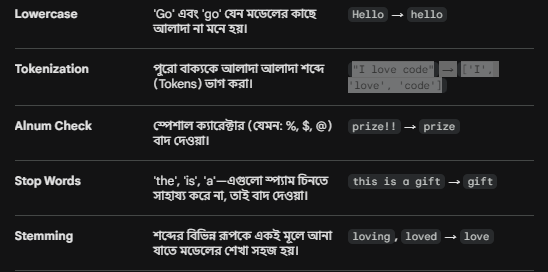


#lowercase
#Tokenization
#Removing special characters
#Removing stop words and punctuation     
#Stemming

In [104]:
#all stop words in the english language
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

# স্টপ-ওয়ার্ড লিস্টটি একবার লোড করে সেট (Set) হিসেবে রাখুন
# সেট ব্যবহার করলে খোঁজার গতি অনেক বেড়ে যায়
stop_words = set(stopwords.words('english'))
#word_tokenize is function of ntlk library which is used to tokenize the text message into words
#here y[]is a list which is used to store the alphanumeric words in the text message
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

 # removing special characters and alphanumeric characters from the text message 
 
    y = []
    for i in text:
        if i.isalnum():
            y.append(i) 
    
    # clone the list in text variable and clear the y list to remove all the stop words and punctuation from the text message
    text = y[:]
    y.clear()

    #removing stop words and punctuation from the text message
    for i in  text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    
    #removing stemming from the text message
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))    
    
    return " ".join(y)
transform_text('Did you liked my presentation? It was awesome!!!')

'like present awesom'

In [ ]:
#all stop words in the english language
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
#punctuation marks in the english language
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
#stemming is the process of reducing a word to its root word
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')
ps.stem('liked')

'like'

In [106]:
# apply the transform_text function to the text column in the dataset and store it in a new column called transformed_text
df['transformed_text'] = df['text'].apply(transform_text)

In [108]:
df.head()

,target,text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [109]:
# ১. Unnamed কলামগুলো মুছে ফেলা
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

# ২. চেক করে দেখুন কলামগুলো গেছে কি না
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [111]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [112]:
from wordcloud import WordCloud
wc = WordCloud(width=50, height=50, min_font_size=10, background_color='white')
